In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

In [5]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_PM2.5(PCC).pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_12116\1586183944.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_12116\1586183944.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 853.09 ± 14.87
Mean Absolute Error: 17.12 ± 0.04
R^2 Score: 0.89 ± 0.0
Mean Absolute Percentage Error: 50.11% ± 3.08%
Normalized RMSE: 0.0294 ± 0.0004


In [2]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\3643243911.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\3643243911.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 242.69 ± 5.82
Mean Absolute Error: 8.33 ± 0.05
R^2 Score: 0.8 ± 0.0
Mean Absolute Percentage Error: 53.19% ± 3.32%
Normalized RMSE: 0.0312 ± 0.0004


In [3]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','PM2.5','Ozone']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\1388878445.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\1388878445.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 222.25 ± 5.1
Mean Absolute Error: 7.91 ± 0.05
R^2 Score: 0.82 ± 0.0
Mean Absolute Percentage Error: 51.93% ± 2.39%
Normalized RMSE: 0.0299 ± 0.0003


In [3]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_12116\2916234419.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_12116\2916234419.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 162.54 ± 1.83
Mean Absolute Error: 6.73 ± 0.04
R^2 Score: 0.87 ± 0.0
Mean Absolute Percentage Error: 39.22% ± 1.36%
Normalized RMSE: 0.0256 ± 0.0001


In [2]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_NO2(PCC).pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_9524\284331378.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_9524\284331378.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 146.62 ± 2.76
Mean Absolute Error: 6.33 ± 0.03
R^2 Score: 0.88 ± 0.0
Mean Absolute Percentage Error: 37.87% ± 1.55%
Normalized RMSE: 0.0243 ± 0.0002


In [8]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','NO2_prev_day','NO2_prev_week']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\2659118245.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\2659118245.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 235.99 ± 3.58
Mean Absolute Error: 8.31 ± 0.04
R^2 Score: 0.81 ± 0.0
Mean Absolute Percentage Error: 55.42% ± 2.94%
Normalized RMSE: 0.0308 ± 0.0002


In [4]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\3225047694.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\3225047694.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 352.86 ± 6.31
Mean Absolute Error: 10.82 ± 0.05
R^2 Score: 0.71 ± 0.0
Mean Absolute Percentage Error: 71.78 ± 4.1%
Normalized RMSE: 3.77 ± 0.03%


In [5]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','PM2.5','Ozone']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\2685437776.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\2685437776.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 328.31 ± 6.38
Mean Absolute Error: 10.44 ± 0.05
R^2 Score: 0.73 ± 0.0
Mean Absolute Percentage Error: 70.28 ± 3.47%
Normalized RMSE: 3.63 ± 0.03%


In [9]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\1216624949.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\1216624949.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 493.11 ± 7.47
Mean Absolute Error: 13.56 ± 0.06
R^2 Score: 0.6 ± 0.0
Mean Absolute Percentage Error: 100.95 ± 3.39%
Normalized RMSE: 4.45 ± 0.03%


In [10]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\1605015634.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\1605015634.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 315.94 ± 5.32
Mean Absolute Error: 10.17 ± 0.05
R^2 Score: 0.74 ± 0.0
Mean Absolute Percentage Error: 69.58 ± 3.81%
Normalized RMSE: 3.56 ± 0.03%


In [11]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','NO2_prev_day','NO2_prev_week']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\2439482849.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\2439482849.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 336.32 ± 5.3
Mean Absolute Error: 10.48 ± 0.05
R^2 Score: 0.73 ± 0.0
Mean Absolute Percentage Error: 70.62 ± 3.12%
Normalized RMSE: 3.68 ± 0.03%


In [17]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','PM2.5','Ozone']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Multiple Linear Regression model
mlr = LinearRegression()

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    mlr.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = mlr.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation


    # Append metrics to lists
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape )
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\4022404620.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_4448\4022404620.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 339.91 ± 0.0
Mean Absolute Error: 13.29 ± 0.05
R^2 Score: 0.59 ± 0.0
Mean Absolute Percentage Error: 92.77 ± 4.04%
Normalized RMSE: 3.7 ± 0.0%


LSTM

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['NO2']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_22492\3843625818.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_22492\3843625818.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,753 (479.50 KB)

 Trainable params: 122,753 (479.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.4332 - mae: 0.3947 - mse: 0.4332 - val_loss: 0.3857 - val_mae: 0.3608 - val_mse: 0.3857
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.4032 - mae: 0.3791 - mse: 0.4032 - val_loss: 0.3740 - val_mae: 0.3624 - val_mse: 0.3740
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.3961 - mae: 0.3746 - mse: 0.3961 - val_loss: 0.3653 - val_mae: 0.3513 - val_mse: 0.3653
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.3937 - mae: 0.3718 - mse: 0.3937 - val_loss: 0.3696 - val_mae: 0.3539 - val_mse: 0.3696
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.3814 - mae: 0.3667 - mse: 0.3814 - val_loss: 0.3520 - val_mae: 0.3442 - val_mse: 0.3520
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.3780 - mae: 0.3643 - mse: 0.3780 - val_loss: 0.3414 - val_mae: 0.3376 - val_mse: 0.3414
Epoch 7/50


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','PM2.5','Ozone']]
y = all_available['NO2']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_22492\3454257861.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_22492\3454257861.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 128)         │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,777 (483.50 KB)

 Trainable params: 123,777 (483.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.4233 - mae: 0.3890 - mse: 0.4233 - val_loss: 0.3582 - val_mae: 0.3508 - val_mse: 0.3582
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.3916 - mae: 0.3715 - mse: 0.3916 - val_loss: 0.3535 - val_mae: 0.3378 - val_mse: 0.3535
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.3760 - mae: 0.3640 - mse: 0.3760 - val_loss: 0.3445 - val_mae: 0.3347 - val_mse: 0.3445
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.3662 - mae: 0.3592 - mse: 0.3662 - val_loss: 0.3279 - val_mae: 0.3307 - val_mse: 0.3279
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.3648 - mae: 0.3558 - mse: 0.3648 - val_loss: 0.3229 - val_mae: 0.3274 - val_mse: 0.3229
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.3531 - mae: 0.3509 - mse: 0.3531 - val_loss: 0.3133 - val_mae: 0.3256 - val_mse: 0.3133
Epoch 7/50


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['NO2']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_22492\76006650.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_22492\76006650.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 128)         │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,313 (489.50 KB)

 Trainable params: 125,313 (489.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.7872 - mae: 0.5804 - mse: 0.7872 - val_loss: 0.6175 - val_mae: 0.4982 - val_mse: 0.6175
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.6323 - mae: 0.5133 - mse: 0.6323 - val_loss: 0.4987 - val_mae: 0.4429 - val_mse: 0.4987
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.5607 - mae: 0.4780 - mse: 0.5607 - val_loss: 0.4664 - val_mae: 0.4421 - val_mse: 0.4664
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.5251 - mae: 0.4626 - mse: 0.5251 - val_loss: 0.4379 - val_mae: 0.4104 - val_mse: 0.4379
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.4981 - mae: 0.4509 - mse: 0.4981 - val_loss: 0.4308 - val_mae: 0.4052 - val_mse: 0.4308
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - loss: 0.4896 - mae: 0.4448 - mse: 0.4896 - val_loss: 0.4114 - val_mae: 0.3964 - val_mse: 0.4114
Epoch 7/50


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['NO2']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_17384\563719437.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_17384\563719437.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,849 (495.50 KB)

 Trainable params: 126,849 (495.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.3869 - mae: 0.3664 - mse: 0.3869 - val_loss: 0.3126 - val_mae: 0.3153 - val_mse: 0.3126
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.3488 - mae: 0.3454 - mse: 0.3488 - val_loss: 0.3057 - val_mae: 0.3151 - val_mse: 0.3057
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.3316 - mae: 0.3394 - mse: 0.3316 - val_loss: 0.2963 - val_mae: 0.3073 - val_mse: 0.2963
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.3270 - mae: 0.3364 - mse: 0.3270 - val_loss: 0.2917 - val_mae: 0.3085 - val_mse: 0.2917
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.3234 - mae: 0.3337 - mse: 0.3234 - val_loss: 0.2867 - val_mae: 0.3076 - val_mse: 0.2867
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.3223 - mae: 0.3322 - mse: 0.3223 - val_loss: 0.2813 - val_mae: 0.2986 - val_mse: 0.2813
Epoch 7/50


Transformer

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2']]
y = all_available['NO2']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for Transformer input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Positional encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, sequence_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_len = sequence_len
        self.d_model = d_model

    def call(self, inputs):
        pos = np.arange(self.sequence_len)[:, np.newaxis]
        i = np.arange(self.d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.d_model))
        angles = pos * angle_rates
        angles[:, 0::2] = np.sin(angles[:, 0::2])  # Apply sin to even indices
        angles[:, 1::2] = np.cos(angles[:, 1::2])  # Apply cos to odd indices
        pos_encoding = angles[np.newaxis, ...]
        return inputs + tf.cast(pos_encoding, tf.float32)

# Transformer Encoder Layer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])

    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x_ff = Dropout(dropout)(x_ff)
    return Add()([x_ff, x])

# Define Transformer-based model
sequence_len = X_train.shape[1]
feature_dim = X_train.shape[2]
head_size = 64
num_heads = 4
ff_dim = 128
dropout = 0.1

input_layer = Input(shape=(sequence_len, feature_dim))
x = PositionalEncoding(sequence_len, feature_dim)(input_layer)

# Add multiple transformer encoder layers
for _ in range(3):  # Number of encoder layers
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1)(x[:, -1, :])  # Use the output of the last time step

model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.4f}")




<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_17384\1544426932.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_17384\1544426932.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 1, 14)     │          0 │ input_layer_1[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 14)     │         28 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 14)     │     15,118 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 14)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 14)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 128)    │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 14)     │      1,806 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1, 14)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 14)     │          0 │ dropout_5[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 14)     │     15,118 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 1, 14)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 14)     │          0 │ dropout_7[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 128)    │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 14)     │      1,806 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1, 14)     │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


9559/9559 ━━━━━━━━━━━━━━━━━━━━ 190s 19ms/step - loss: 0.5042 - mae: 0.4525 - mse: 0.5042 - val_loss: 0.3940 - val_mae: 0.3767 - val_mse: 0.3940
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 239s 23ms/step - loss: 0.4177 - mae: 0.4044 - mse: 0.4177 - val_loss: 0.3405 - val_mae: 0.3485 - val_mse: 0.3405
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 226s 24ms/step - loss: 0.3896 - mae: 0.3881 - mse: 0.3896 - val_loss: 0.3321 - val_mae: 0.3499 - val_mse: 0.3321
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 275s 29ms/step - loss: 0.3734 - mae: 0.3801 - mse: 0.3734 - val_loss: 0.3372 - val_mae: 0.3506 - val_mse: 0.3372
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 278s 29ms/step - loss: 0.3692 - mae: 0.3745 - mse: 0.3692 - val_loss: 0.3173 - val_mae: 0.3493 - val_mse: 0.3173
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 276s 29ms/step - loss: 0.3627 - mae: 0.3710 - mse: 0.3627 - val_loss: 0.3108 - val_mae: 0.3347 - val_mse: 0.3108
Epoch 7/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 254s 27ms/step - loss: 0.3510 - mae: 0.

c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4780/4780 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
MSE: 330.5040
MAE: 11.1714
R²: 0.7286
MAPE: 83.2063%
RMSE: 18.1798


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5']]
y = all_available['NO2']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for Transformer input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Positional encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, sequence_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_len = sequence_len
        self.d_model = d_model

    def call(self, inputs):
        pos = np.arange(self.sequence_len)[:, np.newaxis]
        i = np.arange(self.d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.d_model))
        angles = pos * angle_rates
        angles[:, 0::2] = np.sin(angles[:, 0::2])  # Apply sin to even indices
        angles[:, 1::2] = np.cos(angles[:, 1::2])  # Apply cos to odd indices
        pos_encoding = angles[np.newaxis, ...]
        return inputs + tf.cast(pos_encoding, tf.float32)

# Transformer Encoder Layer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])

    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x_ff = Dropout(dropout)(x_ff)
    return Add()([x_ff, x])

# Define Transformer-based model
sequence_len = X_train.shape[1]
feature_dim = X_train.shape[2]
head_size = 64
num_heads = 4
ff_dim = 128
dropout = 0.1

input_layer = Input(shape=(sequence_len, feature_dim))
x = PositionalEncoding(sequence_len, feature_dim)(input_layer)

# Add multiple transformer encoder layers
for _ in range(3):  # Number of encoder layers
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1)(x[:, -1, :])  # Use the output of the last time step

model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.4f}")




<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23016\3359791153.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_23016\3359791153.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 1, 7)      │          0 │ input_layer[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 7)      │         14 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 7)      │      7,943 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1, 7)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 7)      │          0 │ dropout_1[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 7)      │         14 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 128)    │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 7)      │        903 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 7)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 7)      │          0 │ dropout_2[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 7)      │         14 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 7)      │      7,943 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 7)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 7)      │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 7)      │         14 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 128)    │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 7)      │        903 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1, 7)      │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


9559/9559 ━━━━━━━━━━━━━━━━━━━━ 81s 8ms/step - loss: 0.9039 - mae: 0.6450 - mse: 0.9039 - val_loss: 0.8343 - val_mae: 0.6090 - val_mse: 0.8343
Epoch 2/50
8790/9559 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.8420 - mae: 0.6110 - mse: 0.8420

C:\Users\Faculty\AppData\Local\Temp\ipykernel_23016\3359791153.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


KeyboardInterrupt: 

In [8]:
import pandas as pd
import numpy as np
import pickle

# Load the saved model
model_path = r'D:\Manoj_Honors\random_forest_model_NO2(PCC).pkl'
with open(model_path, 'rb') as file:
    rf_model = pickle.load(file)

# Load the dataset
dataset_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'  # Replace with your dataset path
data = pd.read_csv(dataset_path)

# Drop rows with null values in the required columns for prediction
required_columns = ['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','NO2']
filtered_data = data.dropna(subset=required_columns)

# Extract the input features and actual values
X = filtered_data[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','PM2.5','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y_actual = filtered_data['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Predict PM2.5 values
y_predicted = rf_model.predict(X)

# Create a DataFrame for actual and predicted values
results = pd.DataFrame({
    'Station_ID': filtered_data['Station_ID'],
    'Time': filtered_data['Time'],
    'Lat': filtered_data['Lat'],
    'Lon': filtered_data['Lon'],
    'NO2_Actual': y_actual,
    'NO2_Predicted': y_predicted
})

# Save the results to a CSV file
output_path = 'D:/Manoj_Honors/Final/actual_vs_predicted_NO2.csv'
results.to_csv(output_path, index=False)

print(f"Results saved to '{output_path}'")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_21864\770793908.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Results saved to 'D:/Manoj_Honors/Final/actual_vs_predicted_NO2.csv'


<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_8872\4155442691.py:53: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(thresholds[0], color="red", linestyle="--", label=f"Threshold ({thresholds[0]:.2f} $\mu g/m^3$)")


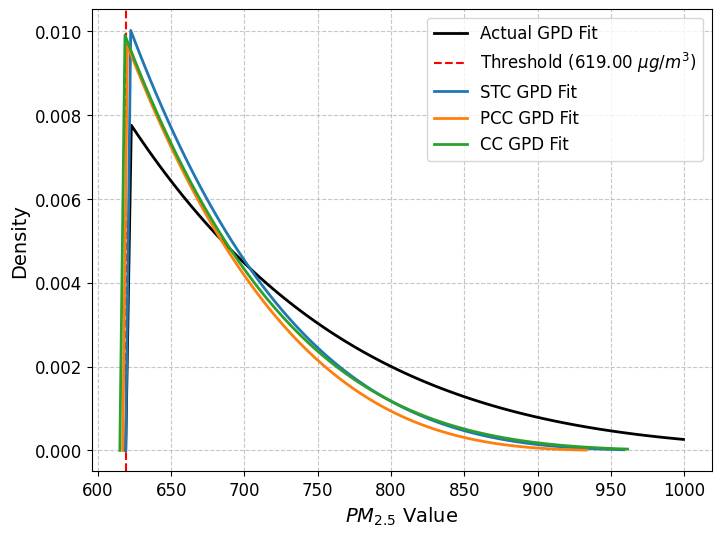

STC - KS Statistic: 0.1260, p-value: 0.0000
PCC - KS Statistic: 0.1217, p-value: 0.0000
CC - KS Statistic: 0.1125, p-value: 0.0000


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, kstest

# Define file paths for Actual, STC, PCC, and CC data
file_paths = {
    "STC": 'D:/Manoj_Honors/Final/STC_actual_vs_predicted_PM2.5.csv',  # Replace with your STC path
    "PCC": 'D:/Manoj_Honors/Final/PCC_actual_vs_predicted_PM2.5.csv',  # Replace with your PCC path
    "CC": 'D:/Manoj_Honors/Final/CC_actual_vs_predicted_PM2.5.csv'     # Replace with your CC path
}

# Function to fit GPD
def fit_gpd(data, threshold):
    exceedances = data - threshold
    params = genpareto.fit(exceedances)
    return params

# Function to process and fit GPD for each model
def process_and_fit_gpd(file_path, threshold_percentile=99.90):
    # Load the data
    data = pd.read_csv(file_path)
    actual = data['PM2.5_Actual'].values
    predicted = data['PM2.5_Predicted'].values

    # Define threshold for extreme values
    threshold = np.percentile(actual, threshold_percentile)
    extreme_actual = actual[actual > threshold]
    extreme_predicted = predicted[predicted > threshold]

    # Fit GPD for actual and predicted values
    gpd_params_actual = fit_gpd(extreme_actual, threshold)
    gpd_params_predicted = fit_gpd(extreme_predicted, threshold)

    # Generate GPD PDFs for comparison
    x_vals = np.linspace(0, max(extreme_actual.max(), extreme_predicted.max()) - threshold, 100)
    gpd_pdf_actual = genpareto.pdf(x_vals, *gpd_params_actual)
    gpd_pdf_predicted = genpareto.pdf(x_vals, *gpd_params_predicted)

    return gpd_pdf_actual, gpd_pdf_predicted, threshold, gpd_params_actual, gpd_params_predicted, extreme_actual, extreme_predicted

# Function to plot GPD fits and Kolmogorov-Smirnov Test
def plot_gpd_comparison_and_ks(model_labels, gpd_pdf_actuals, gpd_pdf_predicted, extremes_actual, extremes_predicted, thresholds, gpd_params_predicted_list):
    # Plot GPD fits for all models
    plt.figure(figsize=(8, 6))  # Increase figure size
    
    # Plot only one "Actual GPD Fit" and threshold
    plt.plot(
        np.linspace(0, extremes_actual[0].max() - thresholds[0], 100) + thresholds[0], 
        gpd_pdf_actuals[0], 
        label="Actual GPD Fit", lw=2, color='black'
    )
    plt.axvline(thresholds[0], color="red", linestyle="--", label=f"Threshold ({thresholds[0]:.2f} $\mu g/m^3$)")

    # Plot for each model in one graph
    for model_label, gpd_pdf_predicted, extreme_predicted, threshold, gpd_params_predicted in zip(model_labels, gpd_pdf_predicted, extremes_predicted, thresholds, gpd_params_predicted_list):
        plt.plot(
            np.linspace(0, extreme_predicted.max() - threshold, 100) + threshold, 
            gpd_pdf_predicted, label=f"{model_label} GPD Fit", lw=2
        )

    # Increase font sizes for better readability

    plt.xlabel("$PM_{2.5}$ Value", fontsize=14)
    plt.ylabel("Density", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Increase legend size
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Kolmogorov-Smirnov Test to Compare Extremes for each model
    for model_label, extreme_actual, gpd_params_predicted, threshold in zip(model_labels, extremes_actual, gpd_params_predicted_list, thresholds):
        ks_stat, ks_p_value = kstest(extreme_actual, lambda x: genpareto.cdf(x - threshold, *gpd_params_predicted))
        print(f"{model_label} - KS Statistic: {ks_stat:.4f}, p-value: {ks_p_value:.4f}")

# Process and fit GPD for STC, PCC, and CC models
gpd_pdf_actual_stc, gpd_pdf_predicted_stc, threshold_stc, gpd_params_actual_stc, gpd_params_predicted_stc, extreme_actual_stc, extreme_predicted_stc = process_and_fit_gpd(file_paths['STC'])
gpd_pdf_actual_pcc, gpd_pdf_predicted_pcc, threshold_pcc, gpd_params_actual_pcc, gpd_params_predicted_pcc, extreme_actual_pcc, extreme_predicted_pcc = process_and_fit_gpd(file_paths['PCC'])
gpd_pdf_actual_cc, gpd_pdf_predicted_cc, threshold_cc, gpd_params_actual_cc, gpd_params_predicted_cc, extreme_actual_cc, extreme_predicted_cc = process_and_fit_gpd(file_paths['CC'])

# Plot all models and perform KS tests
plot_gpd_comparison_and_ks(
    model_labels=["STC", "PCC", "CC"],
    gpd_pdf_actuals=[gpd_pdf_actual_stc, gpd_pdf_actual_pcc, gpd_pdf_actual_cc],
    gpd_pdf_predicted=[gpd_pdf_predicted_stc, gpd_pdf_predicted_pcc, gpd_pdf_predicted_cc],
    extremes_actual=[extreme_actual_stc, extreme_actual_pcc, extreme_actual_cc],
    extremes_predicted=[extreme_predicted_stc, extreme_predicted_pcc, extreme_predicted_cc],
    thresholds=[threshold_stc, threshold_pcc, threshold_cc],
    gpd_params_predicted_list=[gpd_params_predicted_stc, gpd_params_predicted_pcc, gpd_params_predicted_cc]
)


<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_8872\2192488870.py:53: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(thresholds[0], color="red", linestyle="--", label=f"Threshold ({thresholds[0]:.2f} $\mu g/m^3$)")
C:\Users\Faculty\AppData\Local\Temp\ipykernel_8872\2192488870.py:64: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$PM_{2.5}$ Value ($\mu g/m^3$)", fontsize=14)


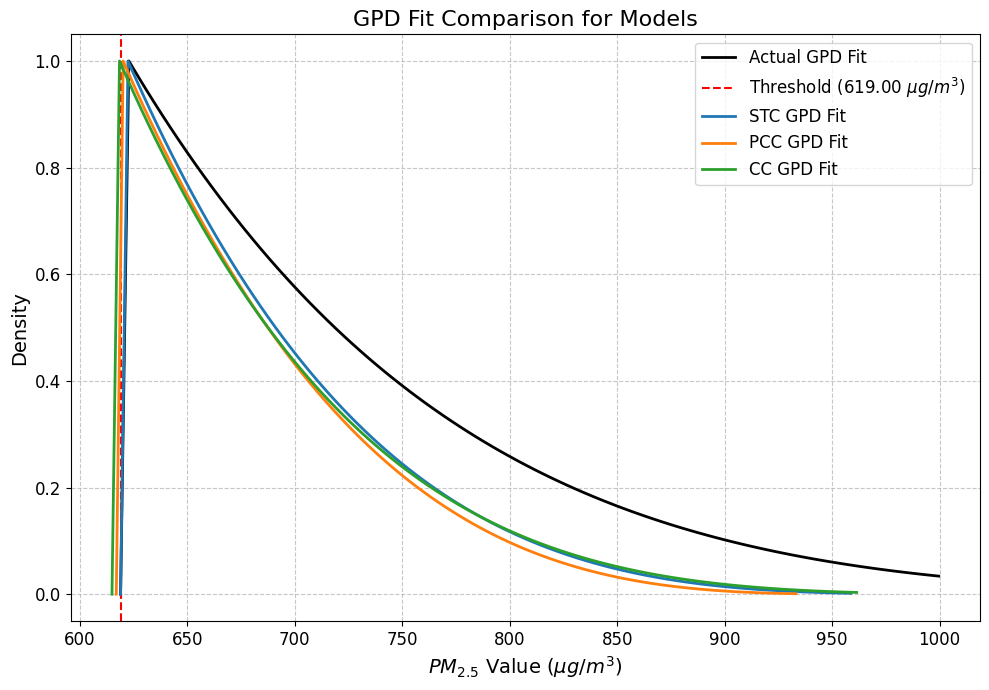

STC - KS Statistic: 0.1260, p-value: 0.0000
PCC - KS Statistic: 0.1217, p-value: 0.0000
CC - KS Statistic: 0.1125, p-value: 0.0000


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, kstest

# Define file paths for Actual, STC, PCC, and CC data
file_paths = {
    "STC": 'D:/Manoj_Honors/Final/STC_actual_vs_predicted_PM2.5.csv',  # Replace with your STC path
    "PCC": 'D:/Manoj_Honors/Final/PCC_actual_vs_predicted_PM2.5.csv',  # Replace with your PCC path
    "CC": 'D:/Manoj_Honors/Final/CC_actual_vs_predicted_PM2.5.csv'     # Replace with your CC path
}

# Function to fit GPD
def fit_gpd(data, threshold):
    exceedances = data - threshold
    params = genpareto.fit(exceedances)
    return params

# Function to process and fit GPD for each model
def process_and_fit_gpd(file_path, threshold_percentile=99.90):
    # Load the data
    data = pd.read_csv(file_path)
    actual = data['PM2.5_Actual'].values
    predicted = data['PM2.5_Predicted'].values

    # Define threshold for extreme values
    threshold = np.percentile(actual, threshold_percentile)
    extreme_actual = actual[actual > threshold]
    extreme_predicted = predicted[predicted > threshold]

    # Fit GPD for actual and predicted values
    gpd_params_actual = fit_gpd(extreme_actual, threshold)
    gpd_params_predicted = fit_gpd(extreme_predicted, threshold)

    # Generate GPD PDFs for comparison
    x_vals = np.linspace(0, max(extreme_actual.max(), extreme_predicted.max()) - threshold, 100)
    gpd_pdf_actual = genpareto.pdf(x_vals, *gpd_params_actual)
    gpd_pdf_predicted = genpareto.pdf(x_vals, *gpd_params_predicted)

    return gpd_pdf_actual, gpd_pdf_predicted, threshold, gpd_params_actual, gpd_params_predicted, extreme_actual, extreme_predicted

# Function to plot GPD fits and Kolmogorov-Smirnov Test
def plot_gpd_comparison_and_ks(model_labels, gpd_pdf_actuals, gpd_pdf_predicted, extremes_actual, extremes_predicted, thresholds, gpd_params_predicted_list):
    # Plot GPD fits for all models
    plt.figure(figsize=(10, 7))  # Larger figure size for better visualization

    # Plot the "Actual GPD Fit" and threshold line once
    plt.plot(
        np.linspace(0, extremes_actual[0].max() - thresholds[0], 100) + thresholds[0],
        gpd_pdf_actuals[0] / max(gpd_pdf_actuals[0]),  # Normalize to start from the top
        label="Actual GPD Fit", lw=2, color='black'
    )
    plt.axvline(thresholds[0], color="red", linestyle="--", label=f"Threshold ({thresholds[0]:.2f} $\mu g/m^3$)")

    # Plot for each model
    for model_label, gpd_pdf_pred, extreme_predicted, threshold in zip(model_labels, gpd_pdf_predicted, extremes_predicted, thresholds):
        plt.plot(
            np.linspace(0, extreme_predicted.max() - threshold, 100) + threshold,
            gpd_pdf_pred / max(gpd_pdf_pred),  # Normalize to start from the top
            label=f"{model_label} GPD Fit", lw=2
        )

    # Customize plot
    plt.xlabel("$PM_{2.5}$ Value ($\mu g/m^3$)", fontsize=14)
    plt.ylabel("Density", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.title("GPD Fit Comparison for Models", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Kolmogorov-Smirnov Test to Compare Extremes for each model
    for model_label, extreme_actual, gpd_params_predicted, threshold in zip(model_labels, extremes_actual, gpd_params_predicted_list, thresholds):
        ks_stat, ks_p_value = kstest(extreme_actual, lambda x: genpareto.cdf(x - threshold, *gpd_params_predicted))
        print(f"{model_label} - KS Statistic: {ks_stat:.4f}, p-value: {ks_p_value:.4f}")

# Process and fit GPD for STC, PCC, and CC models
gpd_pdf_actual_stc, gpd_pdf_predicted_stc, threshold_stc, gpd_params_actual_stc, gpd_params_predicted_stc, extreme_actual_stc, extreme_predicted_stc = process_and_fit_gpd(file_paths['STC'])
gpd_pdf_actual_pcc, gpd_pdf_predicted_pcc, threshold_pcc, gpd_params_actual_pcc, gpd_params_predicted_pcc, extreme_actual_pcc, extreme_predicted_pcc = process_and_fit_gpd(file_paths['PCC'])
gpd_pdf_actual_cc, gpd_pdf_predicted_cc, threshold_cc, gpd_params_actual_cc, gpd_params_predicted_cc, extreme_actual_cc, extreme_predicted_cc = process_and_fit_gpd(file_paths['CC'])

# Plot all models and perform KS tests
plot_gpd_comparison_and_ks(
    model_labels=["STC", "PCC", "CC"],
    gpd_pdf_actuals=[gpd_pdf_actual_stc, gpd_pdf_actual_pcc, gpd_pdf_actual_cc],
    gpd_pdf_predicted=[gpd_pdf_predicted_stc, gpd_pdf_predicted_pcc, gpd_pdf_predicted_cc],
    extremes_actual=[extreme_actual_stc, extreme_actual_pcc, extreme_actual_cc],
    extremes_predicted=[extreme_predicted_stc, extreme_predicted_pcc, extreme_predicted_cc],
    thresholds=[threshold_stc, threshold_pcc, threshold_cc],
    gpd_params_predicted_list=[gpd_params_predicted_stc, gpd_params_predicted_pcc, gpd_params_predicted_cc]
)


<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_8872\3813349857.py:5: SyntaxWarning: invalid escape sequence '\M'
  file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path
C:\Users\Faculty\AppData\Local\Temp\ipykernel_8872\3813349857.py:5: SyntaxWarning: invalid escape sequence '\M'
  file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path


AttributeError: module 'matplotlib' has no attribute 'show'

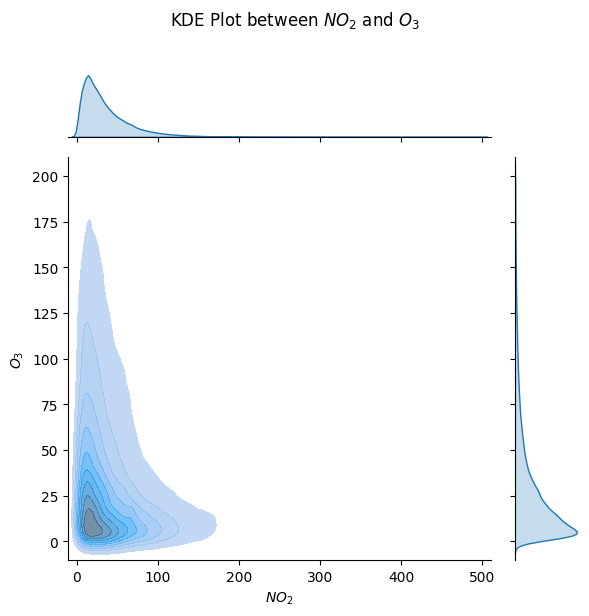

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib as plt
# Assuming `data` is your DataFrame loaded from the CSV file
file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path
data = pd.read_csv(file_path)

# Create the KDE plot
kde_fig = sns.jointplot(
    data=data, 
    x="NO2", 
    y="Ozone", 
    kind='kde', 
    fill=True, 
    hue=None,  # Add hue if you have a categorical variable for color separation
    joint_kws={'alpha': 0.7}
)

# Customize labels
kde_fig.ax_joint.set_xlabel('$NO_2$')
kde_fig.ax_joint.set_ylabel('$O_3$')

# Show the plot
kde_fig.fig.suptitle('KDE Plot between $NO_2$ and $O_3$', y=1.02)  # Adjust title position
kde_fig.fig.tight_layout()
plt.show()
